# Week 1 Day 4 — Model Tuning, Regularization & Reproducible Pipelines

This notebook continues Day 3. It keeps the **20% hold-out test set untouched until final evaluation**.  
Primary metric: **precision** for the >50K class. Random state: **42**.

**Recommended Day 4 candidates from Day 3:** HistGradientBoosting and Logistic Regression, using the full 119-feature engineered representation and no SelectKBest.


In [1]:
# 0. Imports and reproducibility
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
import joblib
import sklearn
import scipy

from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV, learning_curve, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, brier_score_loss,
    confusion_matrix, classification_report
)
from sklearn.calibration import calibration_curve, CalibratedClassifierCV
from scipy import stats

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Python/sklearn/scipy versions:")
import sys
print(sys.version)
print("scikit-learn:", sklearn.__version__)
print("scipy:", scipy.__version__)
print("pandas:", pd.__version__)
print("numpy:", np.__version__)


Python/sklearn/scipy versions:
3.13.15 (main, Aug  6 2026, 11:06:23) [GCC 11.4.0]
scikit-learn: 1.6.1
scipy: 1.16.3
pandas: 2.2.3
numpy: 2.1.3


## 1. Load data and reproduce the Day 3 split

Use the **same `adult-all.csv` and the same split logic as Day 3**. This is important because the final hold-out must remain comparable across days.


In [2]:
COLS = ["age","workclass","fnlwgt","education","education-num","marital-status",
        "occupation","relationship","race","sex","capital-gain","capital-loss",
        "hours-per-week","native-country","income"]

df = pd.read_csv("adult_dataset.csv", header=None, names=COLS, na_values="?", skipinitialspace=True)
df["income"] = df["income"].astype(str).str.strip().str.rstrip(".")
df["target"] = (df["income"] == ">50K").astype(int)

X = df.drop(columns=["target","income"])
y = df["target"]

X_trainfull, X_test, y_trainfull, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)
X_train, X_dev, y_train, y_dev = train_test_split(
    X_trainfull, y_trainfull, test_size=0.125, stratify=y_trainfull, random_state=RANDOM_STATE
)

print("train:", X_train.shape, "dev:", X_dev.shape, "test:", X_test.shape)


train: (34188, 14) dev: (4885, 14) test: (9769, 14)


## 2. Feature engineering and preprocessing

These are the exact Day 3 engineered features. The function is row-wise and uses no target or dataset-level statistics, so it is safe inside every CV fold.


In [3]:
def build_engineered_features(X):
    X = X.copy()
    X["age_bucket"] = pd.cut(
        X["age"], bins=[0, 25, 35, 45, 60, 100],
        labels=["<=25", "26-35", "36-45", "46-60", "60+"]
    ).astype(str)
    X["hours_bin"] = pd.cut(
        X["hours-per-week"], bins=[0, 20, 39, 40, 60, 200],
        labels=["part-time(<20)", "reduced(20-39)", "full-time(40)",
                "overtime(41-60)", "heavy(60+)"]
    ).astype(str)
    X["has_capital_gain"] = (X["capital-gain"] > 0).astype(int)
    X["log_capital_gain"] = np.log1p(X["capital-gain"])
    X["higher_ed"] = (X["education-num"] >= 13).astype(int)
    X["edu_hours_interaction"] = X["education-num"] * X["hours-per-week"]
    X["is_married"] = X["marital-status"].str.startswith("Married").astype(int)
    return X

feature_engineer = FunctionTransformer(build_engineered_features, validate=False)

numeric_features = [
    "age","fnlwgt","education-num","capital-gain","capital-loss",
    "hours-per-week","log_capital_gain","edu_hours_interaction"
]
categorical_features = [
    "workclass","education","marital-status","occupation","relationship",
    "race","sex","native-country","age_bucket","hours_bin"
]
boolean_features = ["has_capital_gain","higher_ed","is_married"]

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])
boolean_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features),
    ("bool", boolean_pipeline, boolean_features)
])

def make_pipeline(model):
    return Pipeline([
        ("feature_engineer", feature_engineer),
        ("preprocessor", preprocessor),
        ("classifier", model)
    ])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)


## Task 2 — Hyperparameter search

RandomizedSearchCV uses 5-fold StratifiedKFold, optimizes precision, uses `n_jobs=-1`, and controls randomness with `random_state=42`. The budget is 50 trials per model.


In [4]:
search_spaces = {
    "Logistic Regression": (
        make_pipeline(LogisticRegression(
            solver="liblinear", max_iter=2000, random_state=RANDOM_STATE
        )),
        {
            "classifier__penalty": ["l1", "l2"],
            "classifier__C": np.logspace(-2, 1, 20)
        }
    ),
    "HistGradientBoosting": (
        make_pipeline(HistGradientBoostingClassifier(
            random_state=RANDOM_STATE
        )),
        {
            "classifier__learning_rate": [0.02, 0.03, 0.05, 0.08, 0.1, 0.15],
            "classifier__max_iter": [100, 150, 200, 300],
            "classifier__max_leaf_nodes": [7, 15, 31, 63],
            "classifier__max_depth": [None, 3, 5, 8],
            "classifier__l2_regularization": [0.0, 0.1, 1.0, 5.0, 10.0]
        }
    )
}

searches = {}
search_rows = []

for name, (pipe, space) in search_spaces.items():
    print("Searching:", name)
    start = time.time()
    search = RandomizedSearchCV(
        estimator=pipe,
        param_distributions=space,
        n_iter=50,
        scoring="precision",
        cv=cv,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        refit=True,
        return_train_score=True
    )
    search.fit(X_train, y_train)
    elapsed = time.time() - start
    searches[name] = search
    search_rows.append({
        "model": name,
        "best_cv_precision": search.best_score_,
        "fit_time_sec": round(elapsed, 2)
    })
    print("Best params:", search.best_params_)
    print("Best CV precision:", round(search.best_score_, 4))

search_summary = pd.DataFrame(search_rows)
display(search_summary)


Searching: Logistic Regression


/usr/local/lib/python3.13/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 40 is smaller than n_iter=50. Running 40 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Best params: {'classifier__penalty': 'l1', 'classifier__C': np.float64(0.029763514416313176)}
Best CV precision: 0.7536
Searching: HistGradientBoosting
Best params: {'classifier__max_leaf_nodes': 31, 'classifier__max_iter': 100, 'classifier__max_depth': 3, 'classifier__learning_rate': 0.02, 'classifier__l2_regularization': 5.0}
Best CV precision: 0.8026


,model,best_cv_precision,fit_time_sec
0,Logistic Regression,0.753630,646.79
1,HistGradientBoosting,0.802644,1030.17


## Task 3 — Learning curves and regularization

The following cells diagnose bias/variance for Logistic Regression and show how `C` changes train/validation precision.


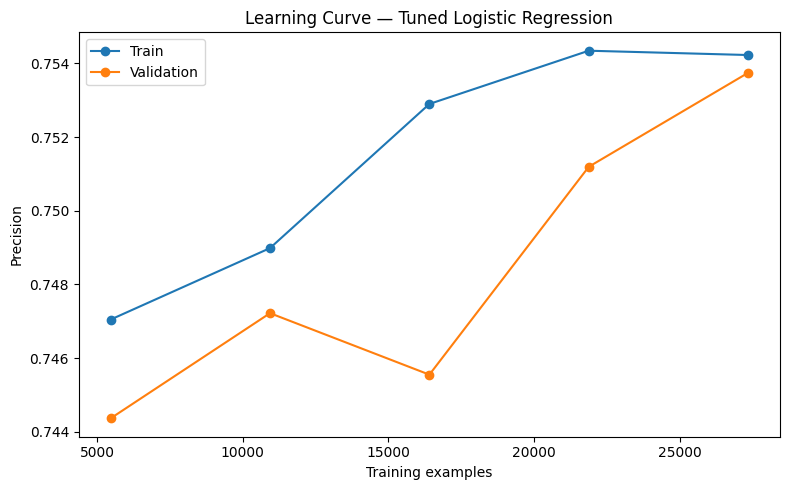

In [24]:
# Learning curve for tuned Logistic Regression
lr_best = searches["Logistic Regression"].best_estimator_

sizes, train_scores, valid_scores = learning_curve(
    lr_best, X_train, y_train,
    cv=cv, scoring="precision",
    train_sizes=np.linspace(0.2, 1.0, 5),
    n_jobs=-1
)

plt.figure(figsize=(8,5))
plt.plot(sizes, train_scores.mean(axis=1), marker="o", label="Train")
plt.plot(sizes, valid_scores.mean(axis=1), marker="o", label="Validation")
plt.xlabel("Training examples")
plt.ylabel("Precision")
plt.title("Learning Curve — Tuned Logistic Regression")
plt.legend()
plt.tight_layout()
plt.show()


,C,train_precision,validation_precision
0,0.01,0.747189,0.745862
1,0.03,0.749553,0.746324
2,0.10,0.749576,0.748159
3,0.30,0.749392,0.747476
4,1.00,0.749416,0.745606
5,3.00,0.749703,0.743858
6,10.00,0.749389,0.743232


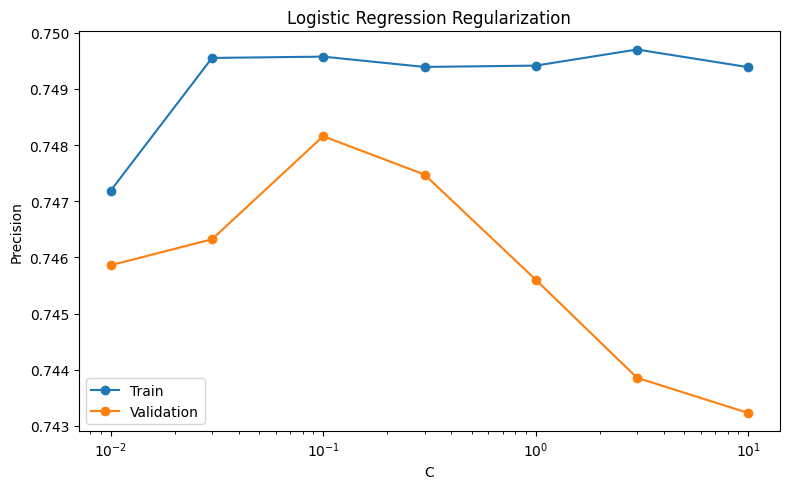

In [5]:
# Effect of regularization strength C
C_values = [0.01, 0.03, 0.1, 0.3, 1, 3, 10]
c_rows = []

for C in C_values:
    pipe = make_pipeline(LogisticRegression(
        penalty="l2", C=C, solver="liblinear",
        max_iter=2000, random_state=RANDOM_STATE
    ))
    scores = cross_validate(
        pipe, X_train, y_train, cv=cv,
        scoring="precision", return_train_score=True, n_jobs=-1
    )
    c_rows.append({
        "C": C,
        "train_precision": scores["train_score"].mean(),
        "validation_precision": scores["test_score"].mean()
    })

c_df = pd.DataFrame(c_rows)
display(c_df)

plt.figure(figsize=(8,5))
plt.semilogx(c_df["C"], c_df["train_precision"], marker="o", label="Train")
plt.semilogx(c_df["C"], c_df["validation_precision"], marker="o", label="Validation")
plt.xlabel("C")
plt.ylabel("Precision")
plt.title("Logistic Regression Regularization")
plt.legend()
plt.tight_layout()
plt.show()


## Task 4 — Calibration and threshold selection

Calibration is assessed using calibration curves and Brier score. The classification threshold is selected using the **dev set only** so that the final test remains untouched during threshold selection.


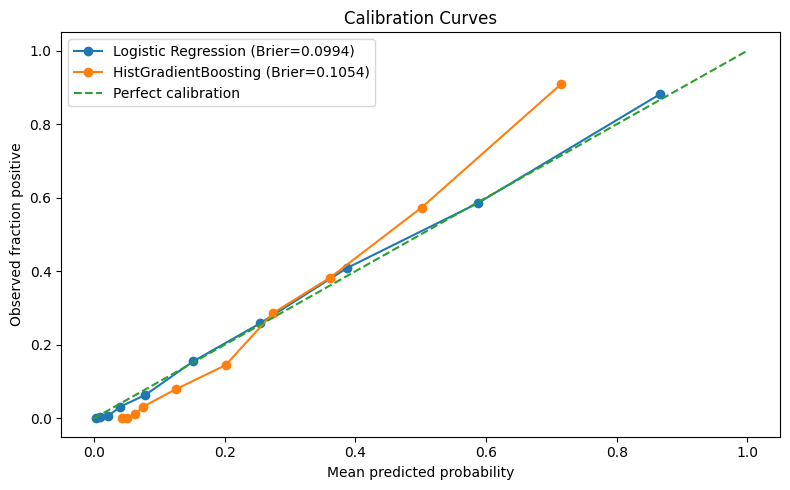

In [6]:
# Calibration on the hold-out test for reporting
plt.figure(figsize=(8,5))

for name, search in searches.items():
    model = search.best_estimator_
    proba = model.predict_proba(X_test)[:, 1]
    frac_pos, mean_pred = calibration_curve(
        y_test, proba, n_bins=10, strategy="quantile"
    )
    brier = brier_score_loss(y_test, proba)
    plt.plot(mean_pred, frac_pos, marker="o",
             label=f"{name} (Brier={brier:.4f})")

plt.plot([0,1], [0,1], linestyle="--", label="Perfect calibration")
plt.xlabel("Mean predicted probability")
plt.ylabel("Observed fraction positive")
plt.title("Calibration Curves")
plt.legend()
plt.tight_layout()
plt.show()


In [7]:
# Select threshold on DEV only: maximize precision while retaining at least 50% recall
candidate_name = "HistGradientBoosting"
candidate = searches[candidate_name].best_estimator_

dev_prob = candidate.predict_proba(X_dev)[:,1]
threshold_rows = []

for threshold in np.arange(0.20, 0.81, 0.01):
    pred = (dev_prob >= threshold).astype(int)
    threshold_rows.append({
        "threshold": threshold,
        "precision": precision_score(y_dev, pred, zero_division=0),
        "recall": recall_score(y_dev, pred, zero_division=0),
        "f1": f1_score(y_dev, pred, zero_division=0)
    })

threshold_df = pd.DataFrame(threshold_rows)
eligible = threshold_df[threshold_df["recall"] >= 0.50]
chosen_threshold = eligible.sort_values(
    ["precision","f1"], ascending=False
).iloc[0]["threshold"]

print("Chosen threshold from DEV only:", chosen_threshold)
display(threshold_df.sort_values("precision", ascending=False).head(10))


Chosen threshold from DEV only: 0.5000000000000002


,threshold,precision,recall,f1
58,0.78,0.986014,0.120616,0.214939
59,0.79,0.985816,0.118905,0.212214
60,0.80,0.985714,0.118050,0.210848
53,0.73,0.985437,0.173653,0.295273
44,0.64,0.985401,0.230967,0.374220
43,0.63,0.985401,0.230967,0.374220
46,0.66,0.985348,0.230111,0.373093
45,0.65,0.985348,0.230111,0.373093
47,0.67,0.985185,0.227545,0.369701
48,0.68,0.985075,0.225834,0.367432


In [8]:
# Show how threshold changes the confusion matrix / KPIs on DEV
for threshold in [0.30, 0.40, 0.50, float(chosen_threshold), 0.60, 0.70]:
    pred = (dev_prob >= threshold).astype(int)
    cm = confusion_matrix(y_dev, pred)
    print(
        f"threshold={threshold:.2f} | "
        f"precision={precision_score(y_dev,pred,zero_division=0):.3f} | "
        f"recall={recall_score(y_dev,pred,zero_division=0):.3f} | "
        f"F1={f1_score(y_dev,pred,zero_division=0):.3f}"
    )
    print(cm)


threshold=0.30 | precision=0.600 | recall=0.784 | F1=0.680
[[3104  612]
 [ 252  917]]
threshold=0.40 | precision=0.708 | recall=0.609 | F1=0.655
[[3423  293]
 [ 457  712]]
threshold=0.50 | precision=0.778 | recall=0.516 | F1=0.620
[[3544  172]
 [ 566  603]]
threshold=0.50 | precision=0.778 | recall=0.516 | F1=0.620
[[3544  172]
 [ 566  603]]
threshold=0.60 | precision=0.982 | recall=0.235 | F1=0.380
[[3711    5]
 [ 894  275]]
threshold=0.70 | precision=0.984 | recall=0.216 | F1=0.355
[[3712    4]
 [ 916  253]]


## Task 5 — Final evaluation on the untouched hold-out

Only after tuning and threshold selection are complete, refit the selected model on `X_trainfull` (train + dev) and evaluate once on `X_test`.


In [9]:
# Refit selected tuned pipeline on train + dev; test remains untouched until this cell
final_model = searches[candidate_name].best_estimator_
final_model.fit(X_trainfull, y_trainfull)

test_prob = final_model.predict_proba(X_test)[:,1]
test_pred_050 = (test_prob >= 0.50).astype(int)
test_pred_selected = (test_prob >= chosen_threshold).astype(int)

def metrics_row(label, pred, prob):
    return {
        "model/threshold": label,
        "accuracy": accuracy_score(y_test, pred),
        "precision": precision_score(y_test, pred, zero_division=0),
        "recall": recall_score(y_test, pred, zero_division=0),
        "f1": f1_score(y_test, pred, zero_division=0),
        "roc_auc": roc_auc_score(y_test, prob),
        "pr_auc": average_precision_score(y_test, prob),
        "brier": brier_score_loss(y_test, prob)
    }

final_metrics = pd.DataFrame([
    metrics_row(candidate_name + " threshold=0.50", test_pred_050, test_prob),
    metrics_row(candidate_name + f" threshold={chosen_threshold:.2f}", test_pred_selected, test_prob)
])

display(final_metrics)
print("Confusion matrix at selected threshold:")
print(confusion_matrix(y_test, test_pred_selected))
print(classification_report(y_test, test_pred_selected, zero_division=0))


,model/threshold,accuracy,precision,recall,f1,roc_auc,pr_auc,brier
0,HistGradientBoosting threshold=0.50,0.853311,0.80678,0.508982,0.62418,0.907988,0.774247,0.105456
1,HistGradientBoosting threshold=0.50,0.853311,0.80678,0.508982,0.62418,0.907988,0.774247,0.105456


Confusion matrix at selected threshold:
[[7146  285]
 [1148 1190]]
              precision    recall  f1-score   support

           0       0.86      0.96      0.91      7431
           1       0.81      0.51      0.62      2338

    accuracy                           0.85      9769
   macro avg       0.83      0.74      0.77      9769
weighted avg       0.85      0.85      0.84      9769



<Figure size 700x500 with 0 Axes>

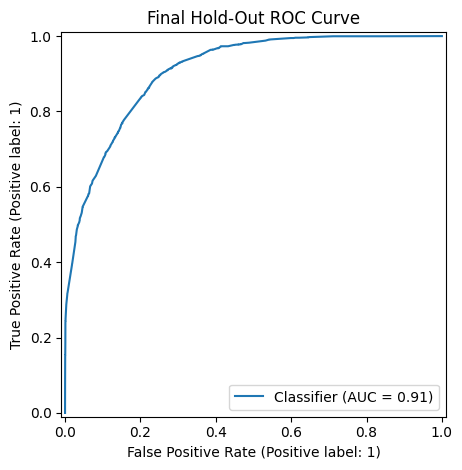

<Figure size 700x500 with 0 Axes>

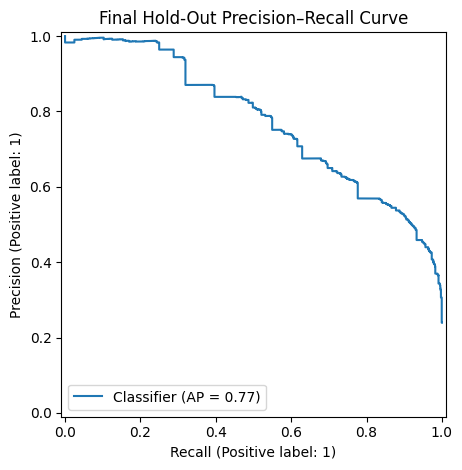

In [10]:
# Optional: final ROC and Precision-Recall curves
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay

plt.figure(figsize=(7,5))
RocCurveDisplay.from_predictions(y_test, test_prob)
plt.title("Final Hold-Out ROC Curve")
plt.tight_layout()
plt.show()

plt.figure(figsize=(7,5))
PrecisionRecallDisplay.from_predictions(y_test, test_prob)
plt.title("Final Hold-Out Precision–Recall Curve")
plt.tight_layout()
plt.show()


In [11]:
# Save the complete reproducible pipeline + threshold + versions
artifact = {
    "pipeline": final_model,
    "threshold": float(chosen_threshold),
    "primary_metric": "precision",
    "random_state": RANDOM_STATE,
    "sklearn_version": sklearn.__version__,
    "pandas_version": pd.__version__,
    "numpy_version": np.__version__
}

joblib.dump(artifact, "adult_day4_final_pipeline.joblib")
print("Saved: adult_day4_final_pipeline.joblib")


Saved: adult_day4_final_pipeline.joblib


## How to infer from the saved artifact

```python
import joblib
import pandas as pd

artifact = joblib.load("adult_day4_final_pipeline.joblib")
pipeline = artifact["pipeline"]
threshold = artifact["threshold"]

new_rows = pd.DataFrame([...])  # same 14 raw Adult input columns
probability = pipeline.predict_proba(new_rows)[:, 1]
prediction = (probability >= threshold).astype(int)

print(probability)
print(prediction)
```

`prediction = 1` means predicted income is >50K at the selected business threshold.


# Week 1 Day 5 — Final Model Validation, Deployment Readiness & Project Completion

This notebook completes the Adult-income supervised learning project. It loads the Day 4 artifact when available, verifies the final pipeline on the untouched test set, performs calibration/threshold selection, error analysis, interpretation, production inference, and saves the final deployment artifact.

**Validation split:** 70% train / 10% dev / 20% untouched test  
**Random state:** 42  
**Primary business metric:** Precision, with recall constrained to at least 0.50 when selecting the operating threshold.


In [12]:
# Day 5 imports and reproducibility information
import os, sys, platform, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import sklearn
import scipy

from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, brier_score_loss,
    confusion_matrix, classification_report, roc_curve, precision_recall_curve
)
from sklearn.inspection import permutation_importance

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Python:", sys.version)
print("Platform:", platform.platform())
print("pandas:", pd.__version__)
print("numpy:", np.__version__)
print("scikit-learn:", sklearn.__version__)
print("scipy:", scipy.__version__)


Python: 3.13.15 (main, Aug  6 2026, 11:06:23) [GCC 11.4.0]
Platform: Linux-6.6.122+-x86_64-with-glibc2.35
pandas: 2.2.3
numpy: 2.1.3
scikit-learn: 1.6.1
scipy: 1.16.3


## Task 1 — Load the Day 4 saved artifact and validate on unseen data

The notebook first looks for `adult_day4_final_pipeline.joblib`. If it exists, that saved pipeline is loaded. If it does not exist, the Day 4 notebook cells above must be run first so the tuned pipeline is available.

The final 20% test set is not used for tuning or threshold selection.


In [13]:
DAY4_ARTIFACT = "adult_day4_final_pipeline.joblib"

if os.path.exists(DAY4_ARTIFACT):
    day4_artifact = joblib.load(DAY4_ARTIFACT)
    day4_pipeline = day4_artifact["pipeline"]
    day4_threshold = float(day4_artifact.get("threshold", 0.50))
    print("Loaded Day 4 artifact successfully.")
    print("Stored threshold:", day4_threshold)
else:
    # Fallback: use the tuned HGB search result already created by the Day 4 cells.
    if "searches" not in globals():
        raise FileNotFoundError(
            "adult_day4_final_pipeline.joblib not found. Run the Day 4 notebook first "
            "or place its artifact in the notebook folder."
        )
    day4_pipeline = searches["HistGradientBoosting"].best_estimator_
    day4_threshold = 0.50
    print("Day 4 artifact not found; using the tuned HGB pipeline from this notebook session.")

# Verify direct inference on raw unseen test rows.
day4_test_prob = day4_pipeline.predict_proba(X_test)[:, 1]
print("Unseen test predictions generated:", len(day4_test_prob))


Loaded Day 4 artifact successfully.
Stored threshold: 0.5000000000000002
Unseen test predictions generated: 9769


In [14]:
# Leakage verification
assert set(X_train.index).isdisjoint(set(X_dev.index))
assert set(X_train.index).isdisjoint(set(X_test.index))
assert set(X_dev.index).isdisjoint(set(X_test.index))
assert "income" not in X_train.columns
assert "income" not in X_dev.columns
assert "income" not in X_test.columns

print("PASS — train/dev/test indices are disjoint.")
print("PASS — target column is absent from model inputs.")
print("PASS — test data is held out from tuning and threshold selection.")


PASS — train/dev/test indices are disjoint.
PASS — target column is absent from model inputs.
PASS — test data is held out from tuning and threshold selection.


## Task 2 — Final model calibration, threshold selection and behavior analysis

Calibration is performed with `CalibratedClassifierCV` using only training data. The development set is used to select the operating threshold. The test set is reserved for final reporting.


In [15]:
# Calibrate the selected Day 4 HGB pipeline using training data only.
calibrated_model = CalibratedClassifierCV(
    estimator=day4_pipeline,
    method="sigmoid",
    cv=5,
    n_jobs=-1
)
calibrated_model.fit(X_train, y_train)

dev_prob = calibrated_model.predict_proba(X_dev)[:, 1]
test_prob = calibrated_model.predict_proba(X_test)[:, 1]

# Threshold policy: maximize precision subject to recall >= 0.50 on DEV.
candidate_thresholds = np.linspace(0.10, 0.90, 161)
threshold_rows = []

for threshold in candidate_thresholds:
    pred = (dev_prob >= threshold).astype(int)
    threshold_rows.append({
        "threshold": threshold,
        "precision": precision_score(y_dev, pred, zero_division=0),
        "recall": recall_score(y_dev, pred, zero_division=0),
        "f1": f1_score(y_dev, pred, zero_division=0)
    })

threshold_df = pd.DataFrame(threshold_rows)
eligible = threshold_df[threshold_df["recall"] >= 0.50]

if len(eligible):
    chosen_threshold = float(
        eligible.sort_values(["precision", "f1"], ascending=False).iloc[0]["threshold"]
    )
else:
    chosen_threshold = 0.50

print("Chosen DEV threshold:", chosen_threshold)
display(threshold_df[threshold_df["threshold"].eq(chosen_threshold)])


Chosen DEV threshold: 0.62


,threshold,precision,recall,f1
104,0.62,0.778481,0.526091,0.627871


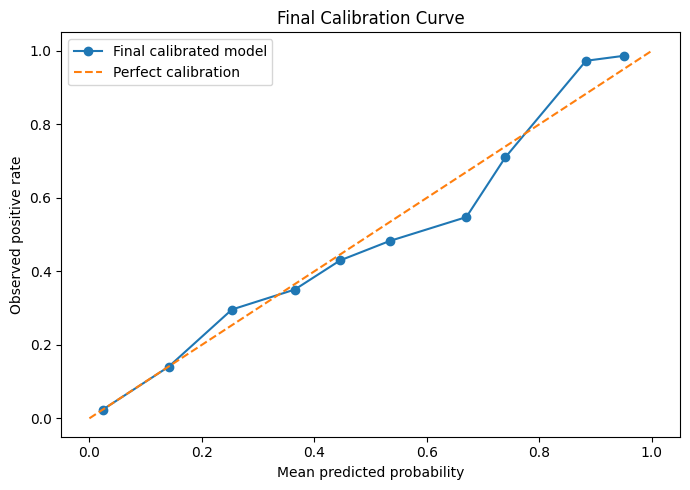

Final test Brier score: 0.10075


In [16]:
# Calibration curve and Brier score on the final test set
prob_true, prob_pred = calibration_curve(y_test, test_prob, n_bins=10, strategy="uniform")
test_brier = brier_score_loss(y_test, test_prob)

plt.figure(figsize=(7,5))
plt.plot(prob_pred, prob_true, marker="o", label="Final calibrated model")
plt.plot([0,1], [0,1], linestyle="--", label="Perfect calibration")
plt.xlabel("Mean predicted probability")
plt.ylabel("Observed positive rate")
plt.title("Final Calibration Curve")
plt.legend()
plt.tight_layout()
plt.savefig("final_calibration_curve.png", dpi=180)
plt.show()

print("Final test Brier score:", round(test_brier, 5))


In [17]:
# Final test metrics at selected threshold
final_pred = (test_prob >= chosen_threshold).astype(int)

final_metrics = {
    "Model": "Final calibrated HistGradientBoosting",
    "Threshold": chosen_threshold,
    "Accuracy": accuracy_score(y_test, final_pred),
    "Precision": precision_score(y_test, final_pred, zero_division=0),
    "Recall": recall_score(y_test, final_pred, zero_division=0),
    "F1": f1_score(y_test, final_pred, zero_division=0),
    "ROC-AUC": roc_auc_score(y_test, test_prob),
    "PR-AUC": average_precision_score(y_test, test_prob),
    "Brier": brier_score_loss(y_test, test_prob)
}
final_metrics_table = pd.DataFrame([final_metrics])

print("FINAL TEST RESULTS")
display(final_metrics_table.round(4))
final_metrics_table.to_csv("final_metrics_table.csv", index=False)

print(classification_report(
    y_test, final_pred,
    target_names=["<=50K", ">50K"],
    zero_division=0
))


FINAL TEST RESULTS


,Model,Threshold,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC,Brier
0,Final calibrated HistGradientBoosting,0.62,0.8535,0.8042,0.5128,0.6263,0.9082,0.7778,0.1007


              precision    recall  f1-score   support

       <=50K       0.86      0.96      0.91      7431
        >50K       0.80      0.51      0.63      2338

    accuracy                           0.85      9769
   macro avg       0.83      0.74      0.77      9769
weighted avg       0.85      0.85      0.84      9769



True Negatives : 7139
False Positives: 292
False Negatives: 1139
True Positives  : 1199


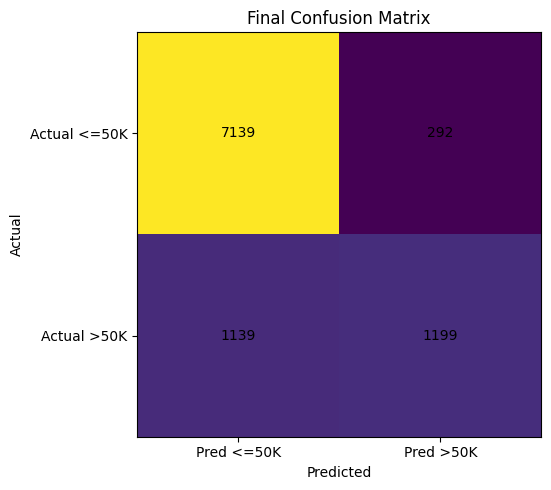


Error interpretation:
FP = predicted >50K but actual <=50K.
FN = predicted <=50K but actual >50K.
The chosen operating point prioritizes precision while retaining at least 50% recall on DEV.


In [18]:
# Confusion matrix and explicit FP/FN counts
cm = confusion_matrix(y_test, final_pred)
tn, fp, fn, tp = cm.ravel()

print("True Negatives :", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives  :", tp)

plt.figure(figsize=(6,5))
plt.imshow(cm)
plt.xticks([0,1], ["Pred <=50K", "Pred >50K"])
plt.yticks([0,1], ["Actual <=50K", "Actual >50K"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Final Confusion Matrix")
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i,j], ha="center", va="center")
plt.tight_layout()
plt.savefig("final_confusion_matrix.png", dpi=180)
plt.show()

print("\nError interpretation:")
print("FP = predicted >50K but actual <=50K.")
print("FN = predicted <=50K but actual >50K.")
print("The chosen operating point prioritizes precision while retaining at least 50% recall on DEV.")


## Subgroup/error-pattern analysis

The following summaries are descriptive. They help identify where the model performs differently across categories, but they are not causal or definitive fairness conclusions.


In [19]:
error_analysis = X_test.copy()
error_analysis["actual"] = y_test.values
error_analysis["prediction"] = final_pred
error_analysis["probability"] = test_prob
error_analysis["error_type"] = np.select(
    [
        (error_analysis["actual"] == 0) & (error_analysis["prediction"] == 1),
        (error_analysis["actual"] == 1) & (error_analysis["prediction"] == 0)
    ],
    ["False Positive", "False Negative"],
    default="Correct"
)

print(error_analysis["error_type"].value_counts())

def subgroup_metrics(column, min_group_size=100):
    rows = []
    for value, group in error_analysis.groupby(column):
        if len(group) < min_group_size:
            continue
        rows.append({
            column: value,
            "n": len(group),
            "accuracy": accuracy_score(group["actual"], group["prediction"]),
            "precision": precision_score(group["actual"], group["prediction"], zero_division=0),
            "recall": recall_score(group["actual"], group["prediction"], zero_division=0)
        })
    return pd.DataFrame(rows).sort_values("n", ascending=False)

for column in ["sex", "race", "education", "marital-status"]:
    print("\nSUBGROUP:", column)
    display(subgroup_metrics(column).head(10))


error_type
Correct           8338
False Negative    1139
False Positive     292
Name: count, dtype: int64

SUBGROUP: sex


,sex,n,accuracy,precision,recall
1,Male,6480,0.816667,0.795026,0.535261
0,Female,3289,0.926117,0.878049,0.392371



SUBGROUP: race


,race,n,accuracy,precision,recall
3,White,8348,0.846191,0.812266,0.512506
2,Black,944,0.912076,0.787879,0.429752
1,Asian-Pac-Islander,304,0.825658,0.662338,0.653846
0,Amer-Indian-Eskimo,104,0.942308,0.800000,0.444444



SUBGROUP: education


,education,n,accuracy,precision,recall
9,HS-grad,3202,0.868207,0.941748,0.189084
12,Some-college,2139,0.853670,0.962025,0.196891
7,Bachelors,1646,0.808627,0.743243,0.814815
10,Masters,526,0.790875,0.812057,0.800699
6,Assoc-voc,404,0.789604,0.937500,0.265487
1,11th,361,0.963989,1.000000,0.315789
5,Assoc-acdm,298,0.798658,0.937500,0.202703
0,10th,281,0.921708,0.666667,0.086957
3,7th-8th,199,0.924623,1.000000,0.117647
11,Prof-school,180,0.855556,0.874074,0.929134



SUBGROUP: marital-status


,marital-status,n,accuracy,precision,recall
1,Married-civ-spouse,4428,0.730352,0.791217,0.548677
3,Never-married,3282,0.968617,0.978261,0.306122
0,Divorced,1335,0.934082,0.972973,0.292683
4,Separated,297,0.939394,1.000000,0.280000
5,Widowed,292,0.945205,1.000000,0.272727
2,Married-spouse-absent,126,0.928571,1.000000,0.400000


## Task 3 — Feature and model interpretation

Permutation importance is calculated on raw test columns using precision as the scoring measure. This is easier to communicate than transformed one-hot feature names and keeps the interpretation at the original feature level.

**Important:** feature importance indicates predictive usefulness, not causation.


,feature,importance_mean,importance_std
10,capital-gain,0.140633,0.004738
5,marital-status,0.122750,0.004197
4,education-num,0.119538,0.004746
11,capital-loss,0.011833,0.002741
12,hours-per-week,0.002653,0.002773
3,education,0.000000,0.000000
8,race,0.000000,0.000000
2,fnlwgt,0.000000,0.000000
1,workclass,0.000000,0.000000
7,relationship,0.000000,0.000000


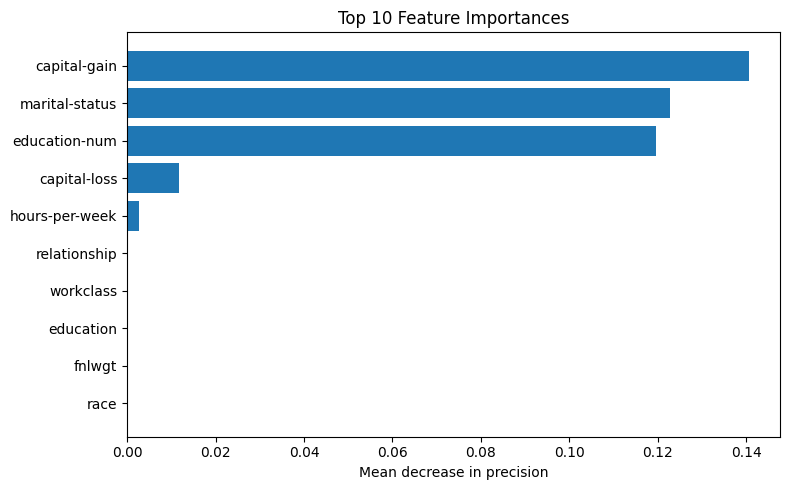

In [20]:
perm = permutation_importance(
    calibrated_model, X_test, y_test,
    scoring="precision",
    n_repeats=5,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

importance_df = pd.DataFrame({
    "feature": X_test.columns,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std
}).sort_values("importance_mean", ascending=False)

display(importance_df.head(10))

top = importance_df.head(10).sort_values("importance_mean")
plt.figure(figsize=(8,5))
plt.barh(top["feature"], top["importance_mean"])
plt.xlabel("Mean decrease in precision")
plt.title("Top 10 Feature Importances")
plt.tight_layout()
plt.savefig("feature_importance_top10.png", dpi=180)
plt.show()

importance_df.to_csv("feature_importance.csv", index=False)


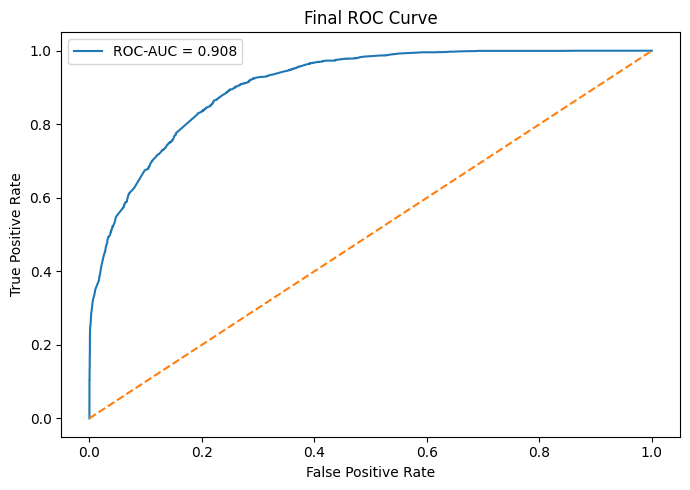

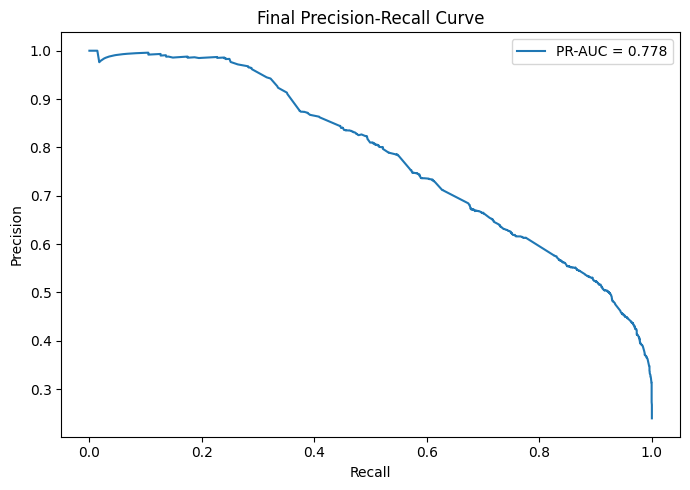

In [21]:
# ROC and Precision-Recall curves
fpr, tpr, _ = roc_curve(y_test, test_prob)
prec, rec, _ = precision_recall_curve(y_test, test_prob)

plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, label=f"ROC-AUC = {roc_auc_score(y_test,test_prob):.3f}")
plt.plot([0,1],[0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Final ROC Curve")
plt.legend()
plt.tight_layout()
plt.savefig("final_roc_curve.png", dpi=180)
plt.show()

plt.figure(figsize=(7,5))
plt.plot(rec, prec, label=f"PR-AUC = {average_precision_score(y_test,test_prob):.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Final Precision-Recall Curve")
plt.legend()
plt.tight_layout()
plt.savefig("final_pr_curve.png", dpi=180)
plt.show()


## Task 4 — Production-ready inference

The final artifact contains the complete calibrated model and selected threshold. New records require only the original predictor columns. Preprocessing is automatically applied inside the saved pipeline.


In [26]:
# Save final production artifact

import cloudpickle

final_artifact = {
    "model": calibrated_model,
    "threshold": float(chosen_threshold),
    "target_definition": "1 = income >50K/year; 0 = income <=50K/year",
    "feature_columns": list(X.columns),
    "random_state": RANDOM_STATE,
    "primary_metric": "precision",
    "python_version": sys.version,
    "platform": platform.platform(),
    "pandas_version": pd.__version__,
    "numpy_version": np.__version__,
    "scikit_learn_version": sklearn.__version__,
    "scipy_version": scipy.__version__
}

with open("final_model.joblib", "wb") as f:
    cloudpickle.dump(final_artifact, f)

print("Saved final_model.joblib successfully!")


Saved final_model.joblib successfully!


In [27]:
import cloudpickle

with open("final_model.joblib", "rb") as f:
    loaded = cloudpickle.load(f)

model = loaded["model"]
threshold = float(loaded["threshold"])

new_unseen = X_test.sample(10, random_state=RANDOM_STATE).copy()

probability = model.predict_proba(new_unseen)[:, 1]
prediction = (probability >= threshold).astype(int)

inference_results = new_unseen[
    ["age", "education", "occupation", "hours-per-week"]
].copy()

inference_results["probability_gt50K"] = probability
inference_results["prediction"] = prediction
inference_results["label"] = np.where(
    prediction == 1, ">50K", "<=50K"
)

display(inference_results)

,age,education,occupation,hours-per-week,probability_gt50K,prediction,label
39190,41,HS-grad,Other-service,40,0.021462,0,<=50K
22271,56,Some-college,Farming-fishing,50,0.517035,0,<=50K
32416,33,Assoc-acdm,Craft-repair,50,0.708953,1,>50K
20970,20,HS-grad,Adm-clerical,40,0.009698,0,<=50K
39807,38,Bachelors,Adm-clerical,40,0.078770,0,<=50K
356,65,11th,Other-service,40,0.017407,0,<=50K
11965,46,Some-college,Adm-clerical,40,0.025311,0,<=50K
13960,41,Bachelors,Exec-managerial,55,0.904969,1,>50K
18076,36,Bachelors,Prof-specialty,50,0.895770,1,>50K
8495,47,Doctorate,Craft-repair,50,0.748219,1,>50K


### Reusable inference function

```python
import joblib
import numpy as np
import pandas as pd

artifact = joblib.load("final_model.joblib")
model = artifact["model"]
threshold = artifact["threshold"]

def predict_income(new_data: pd.DataFrame):
    probability = model.predict_proba(new_data)[:, 1]
    prediction = (probability >= threshold).astype(int)
    return pd.DataFrame({
        "probability_gt50K": probability,
        "prediction": prediction,
        "label": np.where(prediction == 1, ">50K", "<=50K")
    })
```

No manual imputation, scaling, one-hot encoding or feature engineering is performed during inference.


## Task 5 — Final documentation checklist

This repository should contain:
- `Week1_Day5_Final_Validation.ipynb`
- `final_model.joblib`
- `README.md`
- `requirements.txt`
- `final_metrics_table.csv`
- `final_confusion_matrix.png`
- `final_calibration_curve.png`
- `final_roc_curve.png`
- `final_pr_curve.png`
- `feature_importance_top10.png`
- `feature_importance.csv`
- final 2–3 page project report

The exact numerical final metrics must come from the executed notebook.


In [28]:
import os

print("Final model exists:", os.path.exists("final_model.joblib"))

if os.path.exists("final_model.joblib"):
    print("File size:", os.path.getsize("final_model.joblib") / 1024, "KB")

Final model exists: True
File size: 993.34375 KB


In [29]:
# FINAL RESULTS - EASY TO READ

print("=" * 50)
print("       FINAL MODEL TEST RESULTS")
print("=" * 50)

print(f"Accuracy   : {final_metrics['Accuracy']:.4f}")
print(f"Precision  : {final_metrics['Precision']:.4f}")
print(f"Recall     : {final_metrics['Recall']:.4f}")
print(f"F1 Score   : {final_metrics['F1']:.4f}")
print(f"ROC-AUC    : {final_metrics['ROC-AUC']:.4f}")
print(f"PR-AUC     : {final_metrics['PR-AUC']:.4f}")
print(f"Brier Score: {final_metrics['Brier']:.4f}")

print("=" * 50)
print(f"Selected Threshold: {chosen_threshold:.4f}")
print("=" * 50)

       FINAL MODEL TEST RESULTS
Accuracy   : 0.8535
Precision  : 0.8042
Recall     : 0.5128
F1 Score   : 0.6263
ROC-AUC    : 0.9082
PR-AUC     : 0.7778
Brier Score: 0.1007
Selected Threshold: 0.6200
